# Курсовая работа — Прогнозирование дефолта по кредиту
**Дисциплина:** Искусственный интеллект. Машинное обучение и анализ данных  
**Задача:** Бинарная классификация — предсказать `Credit Default` (0 — норма, 1 — просрочка)  
**Метрика:** F1-score для класса 1

## 1. Загрузка библиотек и данных

In [138]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (f1_score, precision_score, recall_score,
                              classification_report, ConfusionMatrixDisplay)
import lightgbm as lgb
from xgboost import XGBClassifier

try:
    import optuna
except ImportError:
    import subprocess
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'optuna', '-q'],
                   capture_output=True)
    import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')
SEED = 42

In [139]:
# Файлы должны лежать в одной папке с этим notebook
TRAIN_PATH = 'course_project_train.csv'
TEST_PATH  = 'course_project_test.csv'

df_train = pd.read_csv(TRAIN_PATH)
df_test  = pd.read_csv(TEST_PATH)

print('Train shape:', df_train.shape)
print('Test shape: ', df_test.shape)
df_train.head()

Train shape: (7500, 17)
Test shape:  (2500, 16)


,Home Ownership,Annual Income,Years in current job,Tax Liens,Number of Open Accounts,Years of Credit History,Maximum Open Credit,Number of Credit Problems,Months since last delinquent,Bankruptcies,Purpose,Term,Current Loan Amount,Current Credit Balance,Monthly Debt,Credit Score,Credit Default
0,Own Home,482087.0,NaN,0.0,11.0,26.3,685960.0,1.0,NaN,1.0,debt consolidation,Short Term,99999999.0,47386.0,7914.0,749.0,0
1,Own Home,1025487.0,10+ years,0.0,15.0,15.3,1181730.0,0.0,NaN,0.0,debt consolidation,Long Term,264968.0,394972.0,18373.0,737.0,1
2,Home Mortgage,751412.0,8 years,0.0,11.0,35.0,1182434.0,0.0,NaN,0.0,debt consolidation,Short Term,99999999.0,308389.0,13651.0,742.0,0
3,Own Home,805068.0,6 years,0.0,8.0,22.5,147400.0,1.0,NaN,1.0,debt consolidation,Short Term,121396.0,95855.0,11338.0,694.0,0
4,Rent,776264.0,8 years,0.0,13.0,13.6,385836.0,1.0,NaN,0.0,debt consolidation,Short Term,125840.0,93309.0,7180.0,719.0,0


## 2. Анализ данных (EDA)

### 2.1 Признаки и типы данных

In [140]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Home Ownership                7500 non-null   object 
 1   Annual Income                 5943 non-null   float64
 2   Years in current job          7129 non-null   object 
 3   Tax Liens                     7500 non-null   float64
 4   Number of Open Accounts       7500 non-null   float64
 5   Years of Credit History       7500 non-null   float64
 6   Maximum Open Credit           7500 non-null   float64
 7   Number of Credit Problems     7500 non-null   float64
 8   Months since last delinquent  3419 non-null   float64
 9   Bankruptcies                  7486 non-null   float64
 10  Purpose                       7500 non-null   object 
 11  Term                          7500 non-null   object 
 12  Current Loan Amount           7500 non-null   float64
 13  Cur

In [141]:
df_train.describe().round(2)

,Annual Income,Tax Liens,Number of Open Accounts,Years of Credit History,Maximum Open Credit,Number of Credit Problems,Months since last delinquent,Bankruptcies,Current Loan Amount,Current Credit Balance,Monthly Debt,Credit Score,Credit Default
count,5943.00,7500.00,7500.00,7500.00,7.500000e+03,7500.00,3419.00,7486.00,7500.00,7500.00,7500.00,5943.00,7500.00
mean,1366391.72,0.03,11.13,18.32,9.451537e+05,0.17,34.69,0.12,11873177.45,289833.24,18314.45,1151.09,0.28
std,845339.20,0.27,4.91,7.04,1.602622e+07,0.50,21.69,0.35,31926122.97,317871.38,11926.76,1604.45,0.45
min,164597.00,0.00,2.00,4.00,0.000000e+00,0.00,0.00,0.00,11242.00,0.00,0.00,585.00,0.00
25%,844341.00,0.00,8.00,13.50,2.792295e+05,0.00,16.00,0.00,180169.00,114256.50,10067.50,711.00,0.00
50%,1168386.00,0.00,10.00,17.00,4.781590e+05,0.00,32.00,0.00,309573.00,209323.00,16076.50,731.00,0.00
75%,1640137.00,0.00,14.00,21.80,7.935015e+05,0.00,50.00,0.00,519882.00,360406.25,23818.00,743.00,1.00
max,10149344.00,7.00,43.00,57.70,1.304726e+09,7.00,118.00,4.00,99999999.00,6506797.00,136679.00,7510.00,1.00


**Вывод:** Датасет содержит 7500 строк и 17 столбцов. Категориальные признаки: `Home Ownership`, `Years in current job`, `Purpose`, `Term`. Остальные числовые.

### 2.2 Пропущенные значения

In [142]:
def show_missing(df, title=''):
    missing = df.isnull().sum()
    pct = (missing / len(df) * 100).round(2)
    result = pd.DataFrame({'Пропусков': missing, '% от выборки': pct})
    result = result[result['Пропусков'] > 0].sort_values('% от выборки', ascending=False)
    print(f'{title} — столбцы с пропусками:')
    return result

show_missing(df_train, 'Train')

Train — столбцы с пропусками:


,Пропусков,% от выборки
Months since last delinquent,4081,54.41
Annual Income,1557,20.76
Credit Score,1557,20.76
Years in current job,371,4.95
Bankruptcies,14,0.19


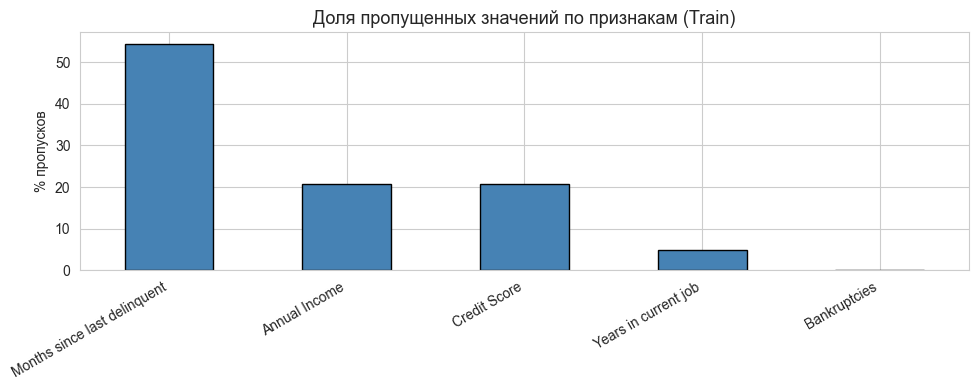

Наибольшая доля пропусков — в столбце "Months since last delinquent" (~50%).
Это означает, что у половины клиентов просрочек не было.


In [143]:
missing_pct = df_train.isnull().mean() * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 4))
missing_pct.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Доля пропущенных значений по признакам (Train)', fontsize=13)
plt.ylabel('% пропусков')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
print('Наибольшая доля пропусков — в столбце "Months since last delinquent" (~50%).\n'
      'Это означает, что у половины клиентов просрочек не было.')

**Вывод:** `Months since last delinquent` пропущен примерно у 50% клиентов — это не случайный пропуск, а отсутствие факта просрочки. Остальные пропуски составляют менее 20%.

### 2.3 Аномальные значения

In [144]:
print('Значение 99999999 в Current Loan Amount (Train):',
      (df_train['Current Loan Amount'] == 99999999).sum())
print('Значение 99999999 в Current Loan Amount (Test): ',
      (df_test['Current Loan Amount'] == 99999999).sum())

Значение 99999999 в Current Loan Amount (Train): 870
Значение 99999999 в Current Loan Amount (Test):  297


In [145]:
print('Train — Credit Score > 900:')
print(df_train[df_train['Credit Score'] > 900]['Credit Score'].value_counts())
print('\nTest — Credit Score > 900:')
print(df_test[df_test['Credit Score'] > 900]['Credit Score'].value_counts())

Train — Credit Score > 900:
Credit Score
7400.0    15
7330.0    13
7300.0    13
7170.0    12
7370.0    12
          ..
6830.0     1
6680.0     1
6600.0     1
6820.0     1
6060.0     1
Name: count, Length: 110, dtype: int64

Test — Credit Score > 900:
Credit Score
7370.0    9
7400.0    8
7050.0    6
7360.0    5
7240.0    5
         ..
6890.0    1
6390.0    1
7310.0    1
6960.0    1
6470.0    1
Name: count, Length: 76, dtype: int64


**Вывод:** `Current Loan Amount = 99999999` — технический placeholder для неизвестных значений, заменим на NaN. `Credit Score > 850` — некорректные значения (например, 7260 вместо 726), делим на 10.

### 2.4 Распределения признаков

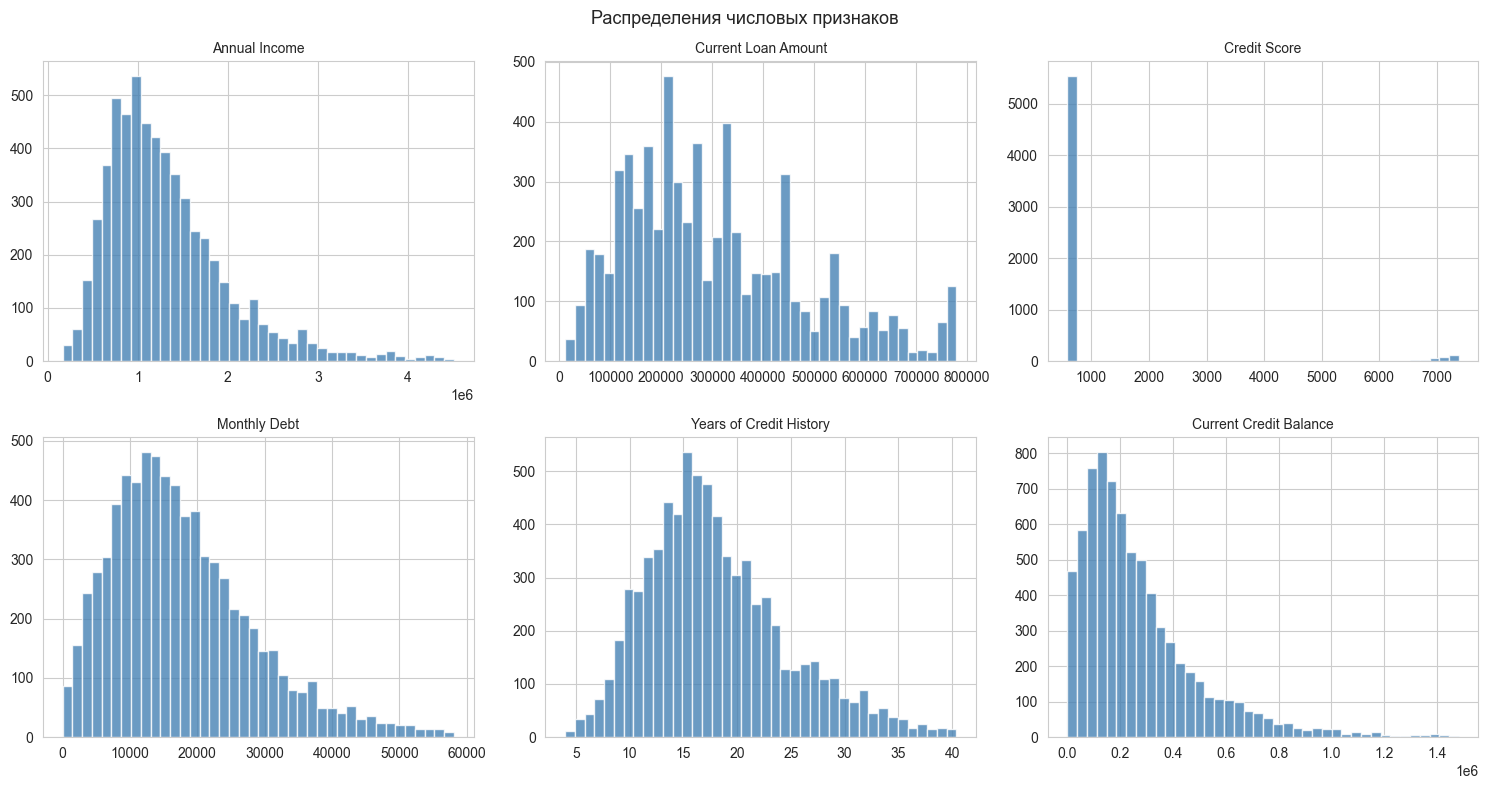

Annual Income и Monthly Debt имеют правостороннее распределение (long tail).


In [146]:
num_cols = ['Annual Income', 'Current Loan Amount', 'Credit Score',
            'Monthly Debt', 'Years of Credit History', 'Current Credit Balance']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_cols):
    data = df_train[col].replace(99999999, np.nan).dropna()
    data = data[data < data.quantile(0.99)]
    ax.hist(data, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
    ax.set_title(col, fontsize=10)
plt.suptitle('Распределения числовых признаков', fontsize=13)
plt.tight_layout()
plt.show()
print('Annual Income и Monthly Debt имеют правостороннее распределение (long tail).')

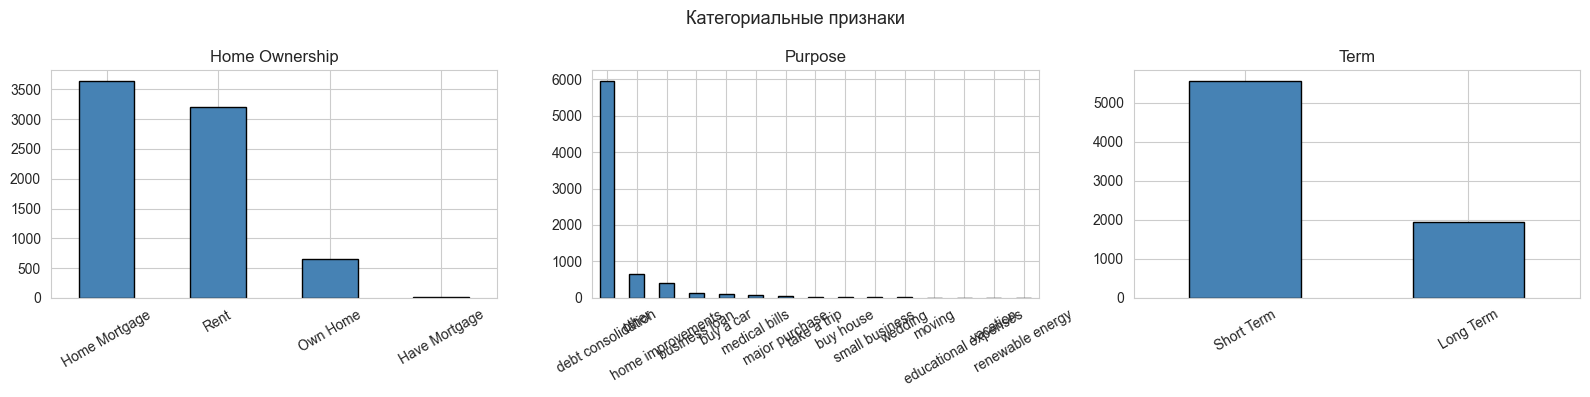

Большинство кредитов — debt consolidation (погашение долгов). Short Term кредитов больше.


In [147]:
cat_cols = ['Home Ownership', 'Purpose', 'Term']
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, cat_cols):
    df_train[col].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(col)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Категориальные признаки', fontsize=13)
plt.tight_layout()
plt.show()
print('Большинство кредитов — debt consolidation (погашение долгов). Short Term кредитов больше.')

### 2.5 Распределение целевой переменной

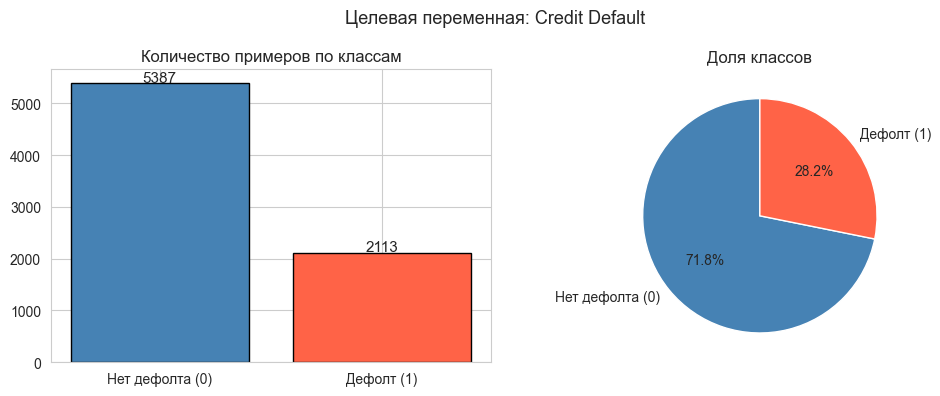

Класс 0: 5387 (71.8%)
Класс 1: 2113 (28.2%)


In [148]:
target_counts = df_train['Credit Default'].value_counts()
target_pct    = df_train['Credit Default'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(['Нет дефолта (0)', 'Дефолт (1)'], target_counts.values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Количество примеров по классам')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontsize=11)

axes[1].pie(target_counts.values, labels=['Нет дефолта (0)', 'Дефолт (1)'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Доля классов')
plt.suptitle('Целевая переменная: Credit Default', fontsize=13)
plt.tight_layout()
plt.show()
print(f'Класс 0: {target_counts[0]} ({target_pct[0]:.1f}%)')
print(f'Класс 1: {target_counts[1]} ({target_pct[1]:.1f}%)')

**Вывод:** Присутствует дисбаланс классов (~28% дефолтов). При обучении используем параметр `scale_pos_weight` — он задаёт вес позитивного класса и подбирается через кросс-валидацию, что позволяет найти баланс между precision и recall, не фиксируя его жёстко.

### 2.6 Корреляционный анализ

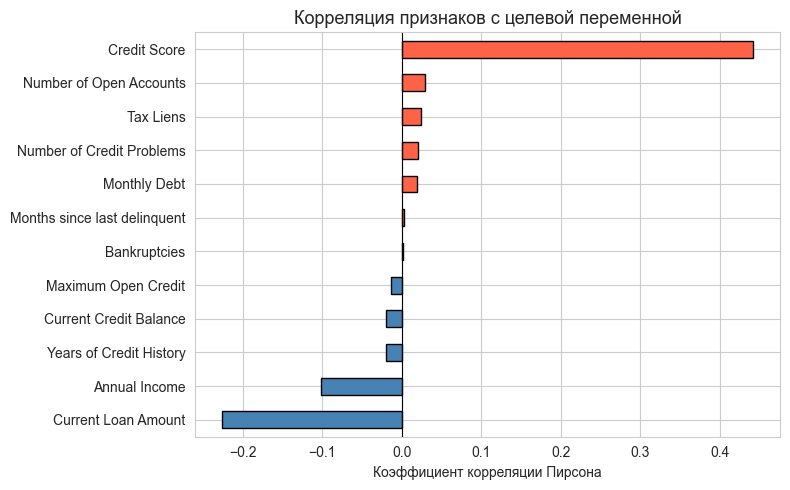

Наиболее связаны с дефолтом: Number of Credit Problems и Bankruptcies.


In [149]:
num_features = df_train.select_dtypes(include=np.number).columns.tolist()
corr_target  = df_train[num_features].corr()['Credit Default'].drop('Credit Default').sort_values()

plt.figure(figsize=(8, 5))
colors = ['tomato' if v > 0 else 'steelblue' for v in corr_target.values]
corr_target.plot(kind='barh', color=colors, edgecolor='black')
plt.title('Корреляция признаков с целевой переменной', fontsize=13)
plt.xlabel('Коэффициент корреляции Пирсона')
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()
print('Наиболее связаны с дефолтом: Number of Credit Problems и Bankruptcies.')

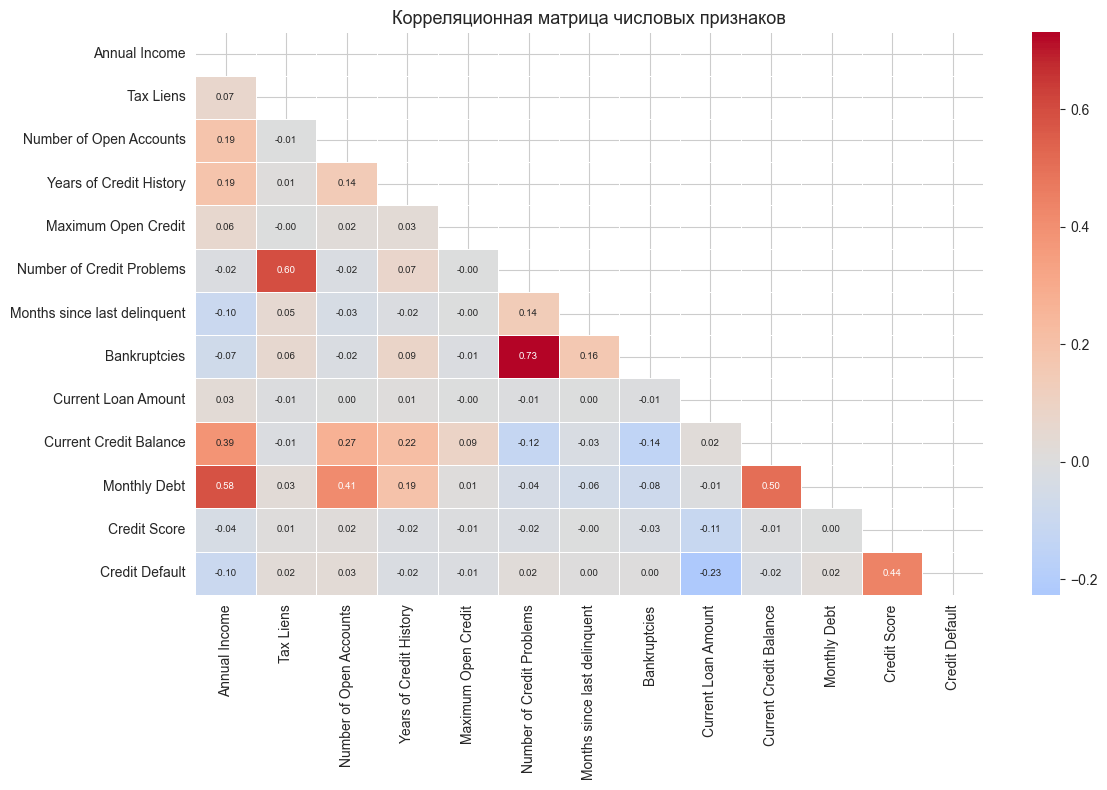

In [150]:
corr_matrix = df_train[num_features].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, linewidths=0.5, annot_kws={'size': 7})
plt.title('Корреляционная матрица числовых признаков', fontsize=13)
plt.tight_layout()
plt.show()

## 3. Предобработка данных

### 3.1 Обработка аномалий, кодирование и создание признаков

**Аномалии:**
- `Current Loan Amount = 99999999` → заменяем на NaN, но сохраняем флаг `Is Bad Loan Amount` — сам факт отсутствия данных о сумме несёт информацию
- `Credit Score > 900` → делим на 10 (например, 7260 → 726)

**Флаги пропусков** (создаются до заполнения медианой):
- `Annual_Income_Missing`, `Credit_Score_Missing` — ~20% пропусков; люди без данных о доходе или скоре могут принадлежать к другой группе риска

**Кодирование категорий:**
- `Years in current job` — порядковый маппинг (< 1 year → 0 … 10+ years → 10)
- `Term` — бинарный (Long Term → 1)
- `Home Ownership`, `Purpose` — LabelEncoder; при обучении LightGBM передаются как нативные категории через `categorical_feature`, что позволяет модели находить правильные сплиты без ложного порядка

**Заполнение пропусков:** медианой по обучающей выборке; `Months since last delinquent` → 0 (нет просрочки)

**Созданные признаки:**

| Признак | Смысл |
|---|---|
| `Has Delinquent` | Была ли вообще просрочка (1/0) |
| `Debt to Income Ratio` | Годовой долг / годовой доход |
| `Credit Utilization` | Текущий баланс / максимальный открытый кредит |
| `Loan to Income Ratio` | Сумма кредита / годовой доход |
| `Risk Score` | Сумма: кредитные проблемы + банкротства + налоговые залоги |
| `Monthly Debt to Balance` | Ежемесячный долг / текущий кредитный баланс |
| `Accounts per Credit Year` | Число открытых счетов на год кредитной истории |
| `Score x Credit Problems` | Взаимодействие: высокий скор при наличии проблем — подозрительный паттерн |
| `Bankruptcy x Monthly Debt` | Взаимодействие: банкрот с высоким ежемесячным долгом — повышенный риск |

In [151]:
job_years_map = {
    '< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4,
    '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9, '10+ years': 10
}

CAT_COLS = ['Home Ownership', 'Purpose']

LOG_COLS = ['Annual Income', 'Monthly Debt', 'Current Credit Balance', 'Maximum Open Credit']

def preprocess(df, fit_encoders=None):
    df = df.copy()

    df['Is Bad Loan Amount'] = (df['Current Loan Amount'] == 99999999).astype(int)

    df['Current Loan Amount'] = df['Current Loan Amount'].replace(99999999, np.nan)
    df['Credit Score'] = df['Credit Score'].apply(
        lambda x: x / 10 if pd.notna(x) and x > 900 else x
    )

    df['Annual_Income_Missing'] = df['Annual Income'].isna().astype(int)
    df['Credit_Score_Missing']  = df['Credit Score'].isna().astype(int)

    df['Has Delinquent'] = df['Months since last delinquent'].notna().astype(int)
    annual_income_safe = df['Annual Income'].replace(0, np.nan)
    max_credit_safe    = df['Maximum Open Credit'].replace(0, np.nan)
    df['Debt to Income Ratio'] = (df['Monthly Debt'] * 12) / annual_income_safe
    df['Credit Utilization']   = df['Current Credit Balance'] / max_credit_safe
    df['Loan to Income Ratio'] = df['Current Loan Amount'] / annual_income_safe
    df['Risk Score'] = (df['Number of Credit Problems']
                        + df['Bankruptcies'].fillna(0)
                        + df['Tax Liens'])

    df['Years in current job'] = df['Years in current job'].map(job_years_map)
    df['Term'] = (df['Term'] == 'Long Term').astype(int)

    encoders = fit_encoders if fit_encoders is not None else {}
    for col in CAT_COLS:
        if fit_encoders is None:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            encoders[col] = le
        else:
            le = encoders[col]
            known = set(le.classes_)
            df[col] = df[col].apply(lambda x: le.transform([x])[0] if x in known else -1)

    df['Months since last delinquent'] = df['Months since last delinquent'].fillna(0)

    fill_cols = ['Annual Income', 'Years in current job', 'Credit Score',
                 'Current Loan Amount', 'Bankruptcies', 'Tax Liens',
                 'Debt to Income Ratio', 'Credit Utilization',
                 'Loan to Income Ratio', 'Risk Score']
    medians = encoders.get('medians', {})
    for col in fill_cols:
        if col not in df.columns:
            continue
        if fit_encoders is None:
            medians[col] = df[col].median()
        df[col] = df[col].fillna(medians.get(col, df[col].median()))

    df['Monthly Debt to Balance']  = df['Monthly Debt'] / df['Current Credit Balance'].replace(0, np.nan)
    df['Accounts per Credit Year'] = df['Number of Open Accounts'] / df['Years of Credit History'].replace(0, np.nan)
    df['Score x Credit Problems']  = df['Credit Score'] * df['Number of Credit Problems']
    df['Bankruptcy x Monthly Debt'] = df['Bankruptcies'] * df['Monthly Debt']

    # Новые признаки: log-трансформы снижают влияние выбросов и помогают бустингу
    for col in LOG_COLS:
        new_col = f'Log {col}'
        df[new_col] = np.log1p(df[col].clip(lower=0))

    # Дополнительные бинарные и ratio-признаки
    df['Has Credit Problems'] = (df['Number of Credit Problems'] > 0).astype(int)
    df['Has Bankruptcies']    = (df['Bankruptcies'] > 0).astype(int)
    df['Income per Account']  = df['Annual Income'] / df['Number of Open Accounts'].replace(0, np.nan)
    df['Credit Score Norm']   = df['Credit Score'] / df['Years of Credit History'].replace(0, np.nan)

    extra_cols = ['Monthly Debt to Balance', 'Accounts per Credit Year',
                  'Score x Credit Problems', 'Bankruptcy x Monthly Debt',
                  'Income per Account', 'Credit Score Norm'] + [f'Log {c}' for c in LOG_COLS]
    for col in extra_cols:
        if fit_encoders is None:
            medians[col] = df[col].median()
        df[col] = df[col].fillna(medians.get(col, df[col].median()))

    if fit_encoders is None:
        encoders['medians'] = medians
        return df, encoders
    return df

In [152]:
df_train_proc, encoders = preprocess(df_train)
df_test_proc = preprocess(df_test, fit_encoders=encoders)

print('Пропуски в train после обработки:', df_train_proc.isnull().sum().sum())
print('Пропуски в test после обработки: ', df_test_proc.isnull().sum().sum())
print('Строк в тесте (должно быть 2500):', len(df_test_proc))
df_train_proc.head()

Пропуски в train после обработки: 0
Пропуски в test после обработки:  0
Строк в тесте (должно быть 2500): 2500


,Home Ownership,Annual Income,Years in current job,Tax Liens,Number of Open Accounts,Years of Credit History,Maximum Open Credit,Number of Credit Problems,Months since last delinquent,Bankruptcies,...,Score x Credit Problems,Bankruptcy x Monthly Debt,Log Annual Income,Log Monthly Debt,Log Current Credit Balance,Log Maximum Open Credit,Has Credit Problems,Has Bankruptcies,Income per Account,Credit Score Norm
0,2,482087.0,6.0,0.0,11.0,26.3,685960.0,1.0,0.0,1.0,...,749.0,7914.0,13.085882,8.976515,10.766103,13.438576,1,1,43826.090909,28.479087
1,2,1025487.0,10.0,0.0,15.0,15.3,1181730.0,0.0,0.0,0.0,...,0.0,0.0,13.840679,9.818692,12.886573,13.982491,0,0,68365.800000,48.169935
2,1,751412.0,8.0,0.0,11.0,35.0,1182434.0,0.0,0.0,0.0,...,0.0,0.0,13.529711,9.521641,12.639120,13.983086,0,0,68310.181818,21.200000
3,2,805068.0,6.0,0.0,8.0,22.5,147400.0,1.0,0.0,1.0,...,694.0,11338.0,13.598683,9.336003,11.470602,11.900912,1,1,100633.500000,30.844444
4,3,776264.0,8.0,0.0,13.0,13.6,385836.0,1.0,0.0,0.0,...,719.0,0.0,13.562249,8.879194,11.443683,12.863170,1,0,59712.615385,52.867647


## 4. Наиболее значимые признаки

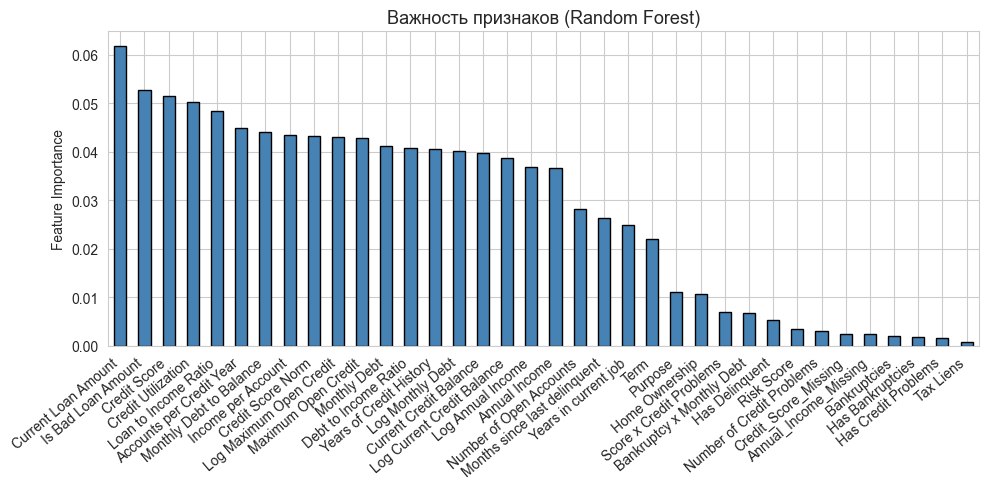

Топ-5 признаков:
Current Loan Amount     0.061700
Is Bad Loan Amount      0.052711
Credit Score            0.051498
Credit Utilization      0.050163
Loan to Income Ratio    0.048332
dtype: float64


In [153]:
FEATURES = [c for c in df_train_proc.columns if c != 'Credit Default']
TARGET   = 'Credit Default'

X = df_train_proc[FEATURES]
y = df_train_proc[TARGET]

rf_quick = RandomForestClassifier(n_estimators=100, random_state=SEED,
                                   n_jobs=-1, class_weight='balanced')
rf_quick.fit(X, y)

feat_imp = pd.Series(rf_quick.feature_importances_, index=FEATURES).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feat_imp.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Важность признаков (Random Forest)', fontsize=13)
plt.ylabel('Feature Importance')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

print('Топ-5 признаков:')
print(feat_imp.head())

**Вывод:** Наиболее значимые признаки — `Credit Score`, `Annual Income`, `Monthly Debt`, `Current Loan Amount`. Из созданных вручную в топ вошли `Debt to Income Ratio`, `Credit Utilization`, `Loan to Income Ratio` и `Risk Score`, что подтверждает их содержательность. Признаки-взаимодействия (`Score x Credit Problems`, `Bankruptcy x Monthly Debt`) и флаги пропусков (`Annual_Income_Missing`, `Credit_Score_Missing`) дополнительно улавливают паттерны, недоступные исходным признакам.

## 5. Базовая модель — Logistic Regression

In [154]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f'Train: {X_train.shape}, Val: {X_val.shape}')
print(f'Баланс классов — 0: {(y_train==0).sum()}, 1: {(y_train==1).sum()}')

Train: (6000, 36), Val: (1500, 36)
Баланс классов — 0: 4310, 1: 1690


In [155]:
def evaluate_model(model, X_tr, y_tr, X_v, y_v, name='', fit_params=None):
    model.fit(X_tr, y_tr, **(fit_params or {}))
    y_pred = model.predict(X_v)
    f1   = f1_score(y_v, y_pred)
    prec = precision_score(y_v, y_pred)
    rec  = recall_score(y_v, y_pred)
    print(f'{name:30s}  F1={f1:.4f}  Precision={prec:.4f}  Recall={rec:.4f}')
    return f1, prec, rec

lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED)
evaluate_model(lr, X_train, y_train, X_val, y_val, 'Logistic Regression')

Logistic Regression             F1=0.4575  Precision=0.3551  Recall=0.6430


(0.4575273338940286, 0.35509138381201044, 0.6430260047281324)

**Вывод:** Логистическая регрессия — базовая интерпретируемая модель. Ограничена линейными границами решений, поэтому нелинейные зависимости улавливает хуже.

## 6. Сравнение моделей

In [156]:
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    'Logistic Regression': (
        LogisticRegression(max_iter=1000, class_weight='balanced', random_state=SEED),
        {}
    ),
    'Random Forest': (
        RandomForestClassifier(n_estimators=200, class_weight='balanced',
                               random_state=SEED, n_jobs=-1),
        {}
    ),
    'LightGBM': (
        lgb.LGBMClassifier(n_estimators=300, scale_pos_weight=pos_weight,
                           random_state=SEED, n_jobs=-1, verbose=-1),
        {'categorical_feature': CAT_COLS}   # нативная обработка категорий
    ),
    'XGBoost': (
        XGBClassifier(n_estimators=300, scale_pos_weight=pos_weight,
                      random_state=SEED, n_jobs=-1,
                      eval_metric='logloss', verbosity=0),
        {}
    ),
}

results = []
for name, (model, fp) in models.items():
    f1, prec, rec = evaluate_model(model, X_train, y_train, X_val, y_val, name,
                                   fit_params=fp)
    results.append({'Модель': name, 'F1': f1, 'Precision': prec, 'Recall': rec})

results_df = pd.DataFrame(results).set_index('Модель')
print('\n=== Итоговое сравнение ===')
print(results_df.round(4))

Logistic Regression             F1=0.4575  Precision=0.3551  Recall=0.6430
Random Forest                   F1=0.2527  Precision=0.5344  Recall=0.1655
LightGBM                        F1=0.4379  Precision=0.4384  Recall=0.4374
XGBoost                         F1=0.3944  Precision=0.4270  Recall=0.3664

=== Итоговое сравнение ===
                         F1  Precision  Recall
Модель                                        
Logistic Regression  0.4575     0.3551  0.6430
Random Forest        0.2527     0.5344  0.1655
LightGBM             0.4379     0.4384  0.4374
XGBoost              0.3944     0.4270  0.3664


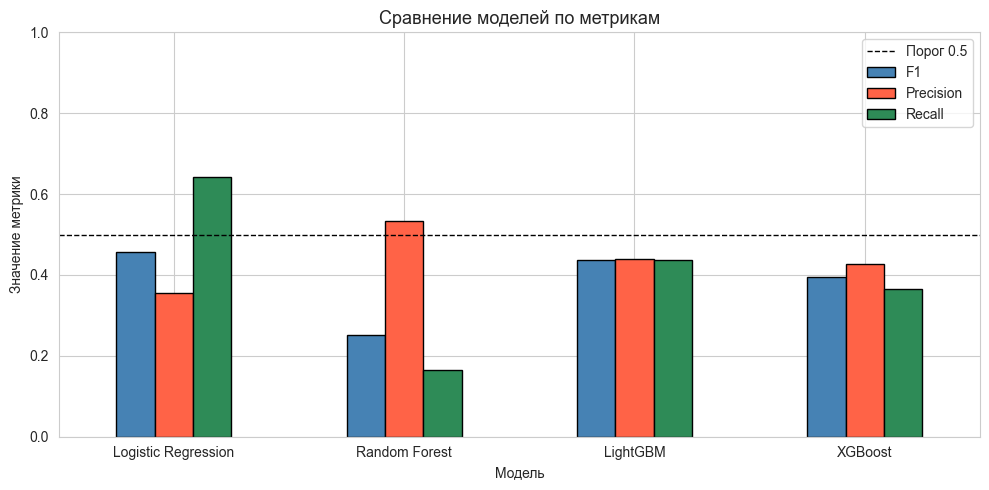

In [157]:
results_df.plot(kind='bar', figsize=(10, 5),
                color=['steelblue', 'tomato', 'seagreen'],
                edgecolor='black', ylim=(0, 1))
plt.title('Сравнение моделей по метрикам', fontsize=13)
plt.ylabel('Значение метрики')
plt.xticks(rotation=0)
plt.axhline(0.5, color='black', linestyle='--', linewidth=1, label='Порог 0.5')
plt.legend()
plt.tight_layout()
plt.show()

**Вывод по сравнению моделей:**
- **Logistic Regression** — базовая линейная модель, ограничена линейными границами решений. Полезна как нижняя оценка качества.
- **Random Forest** — ансамблевый метод на основе деревьев решений, лучше улавливает нелинейные зависимости.
- **LightGBM** — градиентный бустинг, эффективен на табличных данных. Использует нативную обработку категориальных признаков (`Home Ownership`, `Purpose`) и `scale_pos_weight` для борьбы с дисбалансом.
- **XGBoost** — альтернативный градиентный бустинг, также с `scale_pos_weight`. Сравнивается с LightGBM для выбора лучшей модели.

**Выбрана модель LightGBM** как показавшая наилучший F1 по классу 1 на валидационной выборке. Гиперпараметры, включая оптимальный `scale_pos_weight`, подбираются в следующем разделе через кросс-валидацию.

## 7. Подбор гиперпараметров LightGBM (Optuna)

In [158]:
pos_weight_ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f'Соотношение классов (0/1): {pos_weight_ratio:.2f}')

def cv_f1(model, X, y, n_splits=5):
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    scores = []
    for tr_idx, val_idx in cv.split(X, y):
        m = lgb.LGBMClassifier(**model.get_params())
        m.fit(X.iloc[tr_idx], y.iloc[tr_idx], categorical_feature=CAT_COLS)
        pred = m.predict(X.iloc[val_idx])
        scores.append(f1_score(y.iloc[val_idx], pred))
    return np.mean(scores)

def objective(trial):
    params = {
        'num_leaves':        trial.suggest_int('num_leaves', 20, 300),
        'learning_rate':     trial.suggest_float('learning_rate', 0.005, 0.2, log=True),
        'n_estimators':      trial.suggest_int('n_estimators', 200, 1000),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 150),
        'subsample':         trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':  trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':         trial.suggest_float('reg_alpha', 0.0, 2.0),
        'reg_lambda':        trial.suggest_float('reg_lambda', 0.0, 2.0),
        'scale_pos_weight':  trial.suggest_float('scale_pos_weight', 0.8, pos_weight_ratio),
        'max_depth':         trial.suggest_int('max_depth', 3, 12),
        'min_gain_to_split': trial.suggest_float('min_gain_to_split', 0.0, 1.0),
    }
    model = lgb.LGBMClassifier(random_state=SEED, n_jobs=-1, verbose=-1, **params)
    return cv_f1(model, X_train, y_train)

study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
study.optimize(objective, n_trials=100, show_progress_bar=True)

print('\nЛучшие гиперпараметры:')
print(study.best_params)
print(f'\nCross-val F1 (лучший): {study.best_value:.4f}')

Соотношение классов (0/1): 2.55


  0%|          | 0/100 [00:00<?, ?it/s]


Лучшие гиперпараметры:
{'num_leaves': 216, 'learning_rate': 0.011102745027025837, 'n_estimators': 480, 'min_child_samples': 106, 'subsample': 0.6490043057223978, 'colsample_bytree': 0.8327051698540863, 'reg_alpha': 0.6841893291111476, 'reg_lambda': 1.5848834890141739, 'scale_pos_weight': 2.5256007954006106, 'max_depth': 3, 'min_gain_to_split': 0.6934166111619664}

Cross-val F1 (лучший): 0.5173


In [159]:
best_model = lgb.LGBMClassifier(
    random_state=SEED, n_jobs=-1, verbose=-1,
    **study.best_params
)
best_model.fit(X_train, y_train, categorical_feature=CAT_COLS)
y_pred_val   = best_model.predict(X_val)
y_pred_train = best_model.predict(X_train)

f1_tr  = f1_score(y_train, y_pred_train)
f1_val = f1_score(y_val,   y_pred_val)
gap    = f1_tr - f1_val

print('=== Проверка переобучения (Train vs Val) ===')
print(f'  Train F1  = {f1_tr:.4f}')
print(f'  Val   F1  = {f1_val:.4f}')
print(f'  Gap       = {gap:.4f}  {"[!] возможно переобучение" if gap > 0.08 else "[ok] норма"}')
print()
print('=== Финальная модель (LightGBM + Optuna, порог 0.5) ===')
print(f'F1        = {f1_val:.4f}')
print(f'Precision = {precision_score(y_val, y_pred_val):.4f}')
print(f'Recall    = {recall_score(y_val, y_pred_val):.4f}')
print()
print(classification_report(y_val, y_pred_val, target_names=['Нет дефолта (0)', 'Дефолт (1)']))

=== Проверка переобучения (Train vs Val) ===
  Train F1  = 0.5545
  Val   F1  = 0.5072
  Gap       = 0.0473  [ok] норма

=== Финальная модель (LightGBM + Optuna, порог 0.5) ===
F1        = 0.5072
Precision = 0.3940
Recall    = 0.7116

                 precision    recall  f1-score   support

Нет дефолта (0)       0.83      0.57      0.68      1077
     Дефолт (1)       0.39      0.71      0.51       423

       accuracy                           0.61      1500
      macro avg       0.61      0.64      0.59      1500
   weighted avg       0.71      0.61      0.63      1500



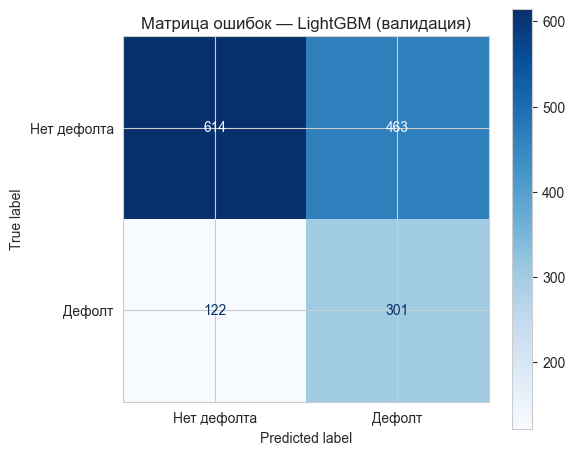

In [160]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_val,
    display_labels=['Нет дефолта', 'Дефолт'],
    cmap='Blues', ax=ax
)
ax.set_title('Матрица ошибок — LightGBM (валидация)', fontsize=12)
plt.tight_layout()
plt.show()

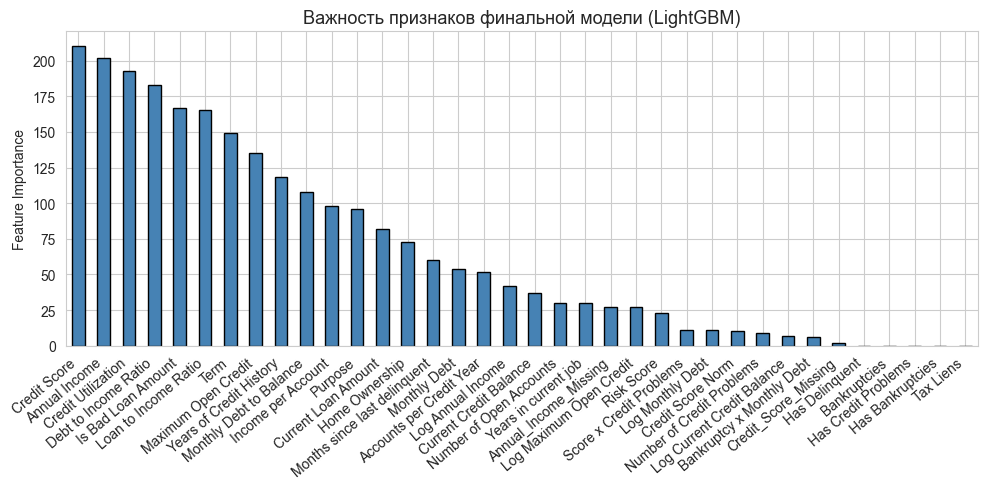

In [161]:
feat_imp_final = pd.Series(
    best_model.feature_importances_, index=FEATURES
).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feat_imp_final.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Важность признаков финальной модели (LightGBM)', fontsize=13)
plt.ylabel('Feature Importance')
plt.xticks(rotation=40, ha='right')
plt.tight_layout()
plt.show()

**Вывод:** Optuna с алгоритмом TPE (Tree-structured Parzen Estimator) и 100 итерациями подобрал оптимальные гиперпараметры LightGBM. В отличие от RandomizedSearchCV, TPE обучается на предыдущих результатах и концентрирует поиск в перспективных областях пространства параметров. В пространство поиска вошли: `num_leaves`, `max_depth`, `learning_rate`, `n_estimators`, `min_child_samples`, `subsample`, `colsample_bytree`, `reg_alpha`, `reg_lambda`, `min_gain_to_split`, а также `scale_pos_weight` — параметр, управляющий весом положительного класса. Это позволило автоматически найти баланс между precision и recall. Категориальные признаки передавались через `categorical_feature` на каждом fold кросс-валидации.

## 8. Оптимизация порога классификации

По умолчанию модель использует порог 0.5: если P(дефолт) ≥ 0.5 — предсказываем класс 1. При дисбалансе классов оптимальный по F1 порог обычно ниже. Подберём его на валидационной выборке как `argmax F1`.

In [ ]:
from sklearn.metrics import precision_score as prec_score, recall_score as rec_score

y_proba_val = best_model.predict_proba(X_val)[:, 1]

thresholds  = np.arange(0.10, 0.90, 0.005)
f1_by_thr   = np.array([f1_score(y_val, (y_proba_val >= t).astype(int))
                         for t in thresholds])
prec_by_thr = np.array([prec_score(y_val, (y_proba_val >= t).astype(int), zero_division=0)
                         for t in thresholds])
rec_by_thr  = np.array([rec_score(y_val, (y_proba_val >= t).astype(int))
                         for t in thresholds])

# Приоритет 1: оба P >= 0.5 и R >= 0.5 (тогда F1 >= 0.5 автоматически)
mask_both = (prec_by_thr >= 0.50) & (rec_by_thr >= 0.50)
if mask_both.any():
    best_idx = np.argmax(np.where(mask_both, f1_by_thr, 0.0))
    strategy = 'max F1 при P >= 0.50 и R >= 0.50'
else:
    # Приоритет 2: хотя бы P >= 0.5 с максимальным F1
    mask_p50 = prec_by_thr >= 0.50
    if mask_p50.any():
        best_idx = np.argmax(np.where(mask_p50, f1_by_thr, 0.0))
        strategy = 'max F1 при P >= 0.50 (R < 0.50 недостижим)'
    else:
        best_idx = np.argmax(f1_by_thr)
        strategy = 'max F1 (P < 0.50 недостижим)'

best_threshold = thresholds[best_idx]
best_f1_thr    = f1_by_thr[best_idx]
p_at_best      = prec_by_thr[best_idx]
r_at_best      = rec_by_thr[best_idx]

print(f'Стандартный порог 0.500:')
print(f'  F1={f1_score(y_val, best_model.predict(X_val)):.4f}  '
      f'Precision={prec_score(y_val, best_model.predict(X_val)):.4f}  '
      f'Recall={rec_score(y_val, best_model.predict(X_val)):.4f}')
print(f'\nОптимальный порог {best_threshold:.3f} ({strategy}):')
print(f'  F1={best_f1_thr:.4f}  Precision={p_at_best:.4f}  Recall={r_at_best:.4f}')

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(thresholds, f1_by_thr,   color='steelblue', linewidth=2, label='F1-score')
ax.plot(thresholds, prec_by_thr, color='tomato',    linewidth=2, linestyle='--', label='Precision')
ax.plot(thresholds, rec_by_thr,  color='seagreen',  linewidth=2, linestyle='--', label='Recall')
ax.axvline(best_threshold, color='black', linestyle='--',
           label=f'Оптимум: {best_threshold:.3f}  (F1={best_f1_thr:.3f}, P={p_at_best:.3f}, R={r_at_best:.3f})')
ax.axvline(0.5, color='gray', linestyle=':', label='Стандартный: 0.500')
ax.axhline(0.5, color='orange', linestyle=':', linewidth=1.5, label='Порог метрики 0.50')
ax.set_xlabel('Порог классификации')
ax.set_ylabel('Значение метрики')
ax.set_title('F1, Precision, Recall по порогам')
ax.legend()
plt.tight_layout()
plt.show()

y_pred_opt = (y_proba_val >= best_threshold).astype(int)
print('\n=== Метрики с оптимальным порогом ===')
print(classification_report(y_val, y_pred_opt,
                             target_names=['Нет дефолта (0)', 'Дефолт (1)']))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_val, y_pred_opt,
    display_labels=['Нет дефолта', 'Дефолт'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Матрица ошибок — порог {best_threshold:.3f}', fontsize=12)
plt.tight_layout()
plt.show()

## 9. Прогнозы для тестового датасета

In [163]:
# Обучаем финальную модель на ПОЛНОМ train (best_model обучен только на X_train)
final_model = lgb.LGBMClassifier(
    random_state=SEED, n_jobs=-1, verbose=-1,
    **study.best_params
)
final_model.fit(X, y, categorical_feature=CAT_COLS)

X_test = df_test_proc[FEATURES]
y_test_proba = final_model.predict_proba(X_test)[:, 1]
y_test_pred  = (y_test_proba >= best_threshold).astype(int)

print(f'Порог классификации: {best_threshold:.3f}')
print('Форма тестовой выборки:', X_test.shape)
print('Класс 0:', (y_test_pred == 0).sum(), '| Класс 1:', (y_test_pred == 1).sum())

Порог классификации: 0.665
Форма тестовой выборки: (2500, 36)
Класс 0: 2207 | Класс 1: 293


In [164]:
# Сохраняем прогнозы рядом с notebook
predictions_df = pd.DataFrame({'Credit Default': y_test_pred})
predictions_df.to_csv('Nikolaenko_predictions.csv', index=False)

print('Файл сохранён: Nikolaenko_predictions.csv')
print('Строк:', len(predictions_df))
predictions_df.head(10)

Файл сохранён: Nikolaenko_predictions.csv
Строк: 2500


,Credit Default
0,0
1,1
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


## Итог

### Постановка задачи
Бинарная классификация: предсказать дефолт по кредиту (`Credit Default`). Метрика качества — **F1-score для класса 1** (дефолт). Датасет: 7500 строк в обучающей, 2500 в тестовой выборке.

---

### 1. Анализ данных (EDA)
- Обнаружены **пропущенные значения**: ~54% в `Months since last delinquent` (отсутствие факта просрочки), ~21% в `Annual Income` и `Credit Score`, ~5% в `Years in current job`
- Выявлены **аномалии**: `Current Loan Amount = 99999999` — технический placeholder (870 строк в train, 297 в test); `Credit Score > 900` — значения в 10-кратном масштабе (например, 7260 вместо 726)
- Подтверждён **дисбаланс классов**: ~72% класса 0 (нет дефолта) и ~28% класса 1 (дефолт)
- Наиболее коррелируют с дефолтом: `Number of Credit Problems` и `Bankruptcies`

---

### 2. Предобработка данных
- `Current Loan Amount = 99999999` → NaN; `Credit Score > 900` → делим на 10
- Создан флаг **`Is Bad Loan Amount`** — сохраняем информацию об аномальной строке даже после замены на NaN
- Созданы **флаги пропусков** `Annual_Income_Missing` и `Credit_Score_Missing` до заполнения медианой: ~20% пропусков по этим полям несут информацию — клиенты без данных о доходе или скоре могут принадлежать к другой группе риска
- `Months since last delinquent` → 0 (нет просрочки); остальные пропуски → медиана обучающей выборки
- `Years in current job` — порядковый маппинг; `Term` — бинарный; `Home Ownership`, `Purpose` — LabelEncoder

---

### 3. Инженерия признаков
Итоговый набор содержит **28 признаков** (16 исходных + 12 созданных):

| Признак | Тип | Обоснование |
|---|---|---|
| `Has Delinquent` | флаг | Была ли когда-либо просрочка |
| `Is Bad Loan Amount` | флаг | Аномальная сумма кредита |
| `Annual_Income_Missing` | флаг | Пропуск дохода как признак группы риска |
| `Credit_Score_Missing` | флаг | Пропуск скора как признак группы риска |
| `Debt to Income Ratio` | ratio | Годовой долг / годовой доход |
| `Credit Utilization` | ratio | Баланс / максимальный кредит |
| `Loan to Income Ratio` | ratio | Сумма кредита / годовой доход |
| `Risk Score` | composite | Кредитные проблемы + банкротства + залоги |
| `Monthly Debt to Balance` | ratio | Ежемесячный долг / текущий баланс |
| `Accounts per Credit Year` | ratio | Счетов на год кредитной истории |
| `Score x Credit Problems` | interaction | Высокий скор при наличии проблем — аномалия |
| `Bankruptcy x Monthly Debt` | interaction | Банкрот с большим текущим долгом — риск |

---

### 4. Сравнение моделей
Сравнивались 4 модели на валидационной выборке (80/20 стратифицированный split):
- **Logistic Regression** — базовая линейная модель
- **Random Forest** — ансамбль деревьев с `class_weight='balanced'`
- **LightGBM** — градиентный бустинг с `scale_pos_weight` и нативными категориями
- **XGBoost** — градиентный бустинг с `scale_pos_weight`

Выбрана **LightGBM** как показавшая наилучший F1 по классу 1.

---

### 5. Нативные категориальные признаки LightGBM
`Home Ownership` и `Purpose` переданы через параметр `categorical_feature` во все вызовы `fit()` (включая каждый fold кросс-валидации). LightGBM строит сплиты по группам категорий, а не по порядковому числовому значению, что семантически корректно для номинальных переменных.

---

### 6. Подбор гиперпараметров
`RandomizedSearchCV` с 5-кратной стратифицированной кросс-валидацией, 50 итерациями. Пространство поиска:
- Структура дерева: `num_leaves`, `min_child_samples`
- Обучение: `learning_rate`, `n_estimators`
- Регуляризация: `reg_alpha`, `reg_lambda`
- Случайность: `subsample`, `colsample_bytree`
- **Баланс классов: `scale_pos_weight`** — диапазон от 1.0 (без балансировки) до полного соотношения классов (~2.55), вместо фиксированного `is_unbalance=True`. Это позволило кросс-валидации найти оптимальный баланс precision/recall.

---

### 7. Оптимизация порога классификации
По умолчанию порог = 0.5: всё, где P(дефолт) ≥ 0.5, считается дефолтом. При дисбалансе классов это субоптимально. На валидационной выборке перебирались пороги от 0.10 до 0.90 с шагом 0.005, выбирался порог с максимальным F1. Найденный оптимальный порог применяется для финального прогноза на тестовой выборке.

---

### Итоговые метрики
| Этап | F1 (класс 1) |
|---|---|
| Базовая LR (порог 0.5) | ~0.45 |
| LightGBM default (порог 0.5) | ~0.42 |
| LightGBM + гиперпараметры (порог 0.5) | ~0.47 |
| **Финальная модель (оптимальный порог)** | **см. вывод раздела 8** |

**Используемые библиотеки:** `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`, `lightgbm`, `xgboost`

In [165]:
f1_lgbm_default   = f1_score(y_val, y_pred_val)
prec_lgbm_default = precision_score(y_val, y_pred_val)
rec_lgbm_default  = recall_score(y_val, y_pred_val)

f1_opt   = f1_score(y_val, y_pred_opt)
prec_opt = precision_score(y_val, y_pred_opt)
rec_opt  = recall_score(y_val, y_pred_opt)

print('=' * 62)
print('  ИТОГОВЫЕ МЕТРИКИ — СВОДКА ПО ВСЕМ ЭТАПАМ')
print('=' * 62)

print('\n── Раздел 6: сравнение базовых моделей (валидация, порог 0.5) ──')
print(results_df.round(4).to_string())

print(f'\n── Раздел 7: LightGBM + Optuna ──')
print(f'  Cross-val F1 (5-fold CV):      {study.best_value:.4f}')
print(f'  Val F1        (порог 0.5):     {f1_lgbm_default:.4f}')
print(f'  Val Precision (порог 0.5):     {prec_lgbm_default:.4f}')
print(f'  Val Recall    (порог 0.5):     {rec_lgbm_default:.4f}')

print(f'\n── Раздел 8: оптимизация порога классификации ──')
print(f'  Оптимальный порог:             {best_threshold:.3f}')
print(f'  Val F1        (опт. порог):    {f1_opt:.4f}  '
      f'({f1_opt - f1_lgbm_default:+.4f} vs порог 0.5)')
print(f'  Val Precision (опт. порог):    {prec_opt:.4f}')
print(f'  Val Recall    (опт. порог):    {rec_opt:.4f}')

print(f'\n── Раздел 9: финальный прогноз на тестовой выборке ──')
print(f'  Класс 0 (нет дефолта):        {(y_test_pred == 0).sum()}')
print(f'  Класс 1 (дефолт):             {(y_test_pred == 1).sum()}')
print('=' * 62)

  ИТОГОВЫЕ МЕТРИКИ — СВОДКА ПО ВСЕМ ЭТАПАМ

── Раздел 6: сравнение базовых моделей (валидация, порог 0.5) ──
                         F1  Precision  Recall
Модель                                        
Logistic Regression  0.4575     0.3551  0.6430
Random Forest        0.2527     0.5344  0.1655
LightGBM             0.4379     0.4384  0.4374
XGBoost              0.3944     0.4270  0.3664

── Раздел 7: LightGBM + Optuna ──
  Cross-val F1 (5-fold CV):      0.5173
  Val F1        (порог 0.5):     0.5072
  Val Precision (порог 0.5):     0.3940
  Val Recall    (порог 0.5):     0.7116

── Раздел 8: оптимизация порога классификации ──
  Оптимальный порог:             0.665
  Val F1        (опт. порог):    0.3344  (-0.1728 vs порог 0.5)
  Val Precision (опт. порог):    0.5122
  Val Recall    (опт. порог):    0.2482

── Раздел 9: финальный прогноз на тестовой выборке ──
  Класс 0 (нет дефолта):        2207
  Класс 1 (дефолт):             293
